# PINN para reconstruir el campo de velocidades

Versión limpia basada en el Problema 4 de `E1-TAPIA-ORDOÑEZ.ipynb`.

La estructura es:

1. Cargar las tres trayectorias experimentales.
2. Definir una red independiente para cada trayectoria.
3. Preentrenar las redes usando solamente los datos.
4. Activar la restricción física de Burgers.
5. Aprender los parámetros físicos compartidos.
6. Reconstruir el campo de velocidades y compararlo con las trayectorias.


## 1. Librerías y configuración


In [38]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

torch.manual_seed(1234)
np.random.seed(1234)

device = torch.device(
    "cuda:0" if torch.cuda.is_available() else "cpu"
)

print("Dispositivo:", device)

plt.rcParams.update({
    "figure.figsize": (8, 7),
    "axes.grid": True,
    "font.family": "STIXGeneral",
    "mathtext.fontset": "cm",
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "legend.fontsize": 12,
})


Dispositivo: cpu


## 2. Cargar las tres trayectorias


In [42]:
CARPETA = Path(
    r"C:\Users\user\Desktop\Labo5\1_Fluidos\datos\crudos"
)

ARCHIVOS = [
    CARPETA / "trayectoria1_PINN.csv",
    CARPETA / "trayectoria2_PINN.csv",
    CARPETA / "trayectoria3_PINN.csv",
]

dfs = []

for archivo in ARCHIVOS:

    df = pd.read_csv(archivo)

    # Eliminar filas incompletas, si hubiera
    df = df.dropna(
        subset=["t_s", "x_m", "y_m"]
    ).reset_index(drop=True)

    dfs.append(df)


for i, df in enumerate(dfs, start=1):

    print(
        f"Trayectoria {i}: "
        f"{len(df)} puntos | "
        f"T = {df['t_s'].max():.3f} s"
    )


Trayectoria 1: 232 puntos | T = 3.855 s
Trayectoria 2: 157 puntos | T = 2.603 s
Trayectoria 3: 241 puntos | T = 4.005 s


## 3. Visualización de las trayectorias experimentales


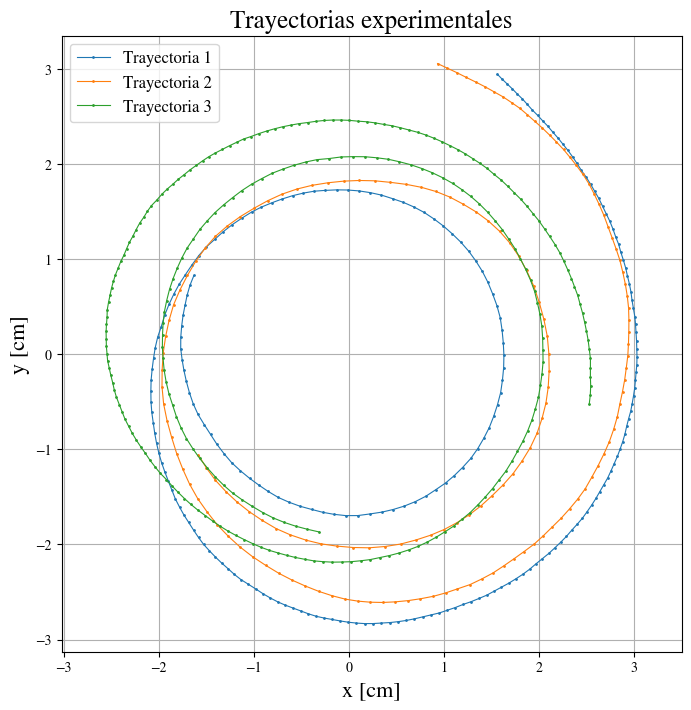

In [43]:
fig, ax = plt.subplots(
    figsize=(8, 8)
)

for i, df in enumerate(dfs, start=1):

    ax.plot(
        100 * df["x_m"],
        100 * df["y_m"],
        ".-",
        ms=2,
        lw=0.8,
        label=f"Trayectoria {i}"
    )

ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Trayectorias experimentales")
ax.axis("equal")
ax.legend()

plt.show()


## 4. Red neuronal

Cada trayectoria tiene su propia red neuronal.

Las tres redes comparten los mismos parámetros físicos del vórtice.


In [44]:
class MLP(torch.nn.Module):

    def __init__(self, sizes):
        super().__init__()

        self.layers = torch.nn.ModuleList()

        for i in range(len(sizes) - 1):
            self.layers.append(
                torch.nn.Linear(
                    sizes[i],
                    sizes[i + 1]
                )
            )

    def forward(self, x):

        h = x

        for layer in self.layers[:-1]:
            h = torch.tanh(
                layer(h)
            )

        return self.layers[-1](h)

## 5. Parámetros físicos compartidos


In [45]:
class ParametrosVortice(torch.nn.Module):

    def __init__(self):
        super().__init__()

        # Parámetros internos sin restricción.
        # softplus fuerza alpha > 0 y r0 > 0.

        self.alp_raw = torch.nn.Parameter(
            torch.tensor(
                [-3.0],
                dtype=torch.float32
            )
        )

        self.Gam = torch.nn.Parameter(
            torch.tensor(
                [0.008],
                dtype=torch.float32
            )
        )

        self.r0_raw = torch.nn.Parameter(
            torch.tensor(
                [-4.0],
                dtype=torch.float32
            )
        )

        # Corrección del centro del vórtice
        # respecto del origen usado en los CSV.

        self.xc = torch.nn.Parameter(
            torch.tensor(
                [0.0],
                dtype=torch.float32
            )
        )

        self.yc = torch.nn.Parameter(
            torch.tensor(
                [0.0],
                dtype=torch.float32
            )
        )


    @property
    def alp(self):

        return torch.nn.functional.softplus(
            self.alp_raw
        )


    @property
    def r0(self):

        return torch.nn.functional.softplus(
            self.r0_raw
        )


parametros = ParametrosVortice().to(device)


## 6. Campo de velocidades de Burgers


In [46]:
def velocidad_burgers(X, parametros):

    x = X[:, 0]
    y = X[:, 1]

    xr = x - parametros.xc
    yr = y - parametros.yc

    r2 = (
        xr**2
        + yr**2
        + 1e-12
    )

    comun = (
        parametros.Gam
        / (2 * torch.pi * r2)
        * (
            1
            - torch.exp(
                -r2 / parametros.r0**2
            )
        )
    )

    vx = (
        -parametros.alp * xr
        - yr * comun
    )

    vy = (
        -parametros.alp * yr
        + xr * comun
    )

    return torch.stack(
        (vx, vy),
        dim=1
    )


## 7. Preparar los datos para Torch

Se usan todos los puntos experimentales.

El tiempo de cada trayectoria se normaliza al intervalo [-1, 1].


In [54]:
datos_torch = []

for df in dfs:

    t = torch.tensor(
        df["t_s"].values,
        dtype=torch.float32,
        device=device
    ).view(-1, 1)

    X = torch.tensor(
        df[["x_m", "y_m"]].values,
        dtype=torch.float32,
        device=device
    )

    T = float(
        df["t_s"].max()
    )

    tau = (
        2 * t / T
        - 1
    )

    datos_torch.append({
        "tau": tau,
        "X": X,
        "T": T,
    })


## 8. Crear las tres redes


In [48]:
pinns = torch.nn.ModuleList([
    MLP([1, 80, 80, 80, 80, 2]),
    MLP([1, 80, 80, 80, 80, 2]),
    MLP([1, 80, 80, 80, 80, 2]),
]).to(device)

## 9. Etapa 1: preentrenamiento solo con datos

Primero se obliga a cada red a representar correctamente su trayectoria experimental.

Todavía no se usa la ecuación física.


In [55]:
# ============================================================
# PREENTRENAMIENTO SOLO CON DATOS
# ============================================================

# Escala espacial característica del experimento
L0 = 0.03  # m


optimizer_datos = torch.optim.Adam(
    pinns.parameters(),
    lr=1e-3
)


ITERACIONES_DATOS = 20000


loss_pre = np.zeros(
    ITERACIONES_DATOS
)


for epoch in range(
    ITERACIONES_DATOS
):

    optimizer_datos.zero_grad()

    MSDd = 0.0


    for pinn, datos in zip(
        pinns,
        datos_torch
    ):

        X_pred = pinn(
            datos["tau"]
        )


        # Error de datos adimensionalizado
        MSDd_i = torch.mean(
            (
                (
                    X_pred
                    - datos["X"]
                )
                / L0
            )**2
        )


        MSDd = (
            MSDd
            + MSDd_i
        )


    # Promedio sobre las tres trayectorias
    MSDd = (
        MSDd
        / len(pinns)
    )


    MSDd.backward()

    optimizer_datos.step()


    loss_pre[epoch] = (
        MSDd
        .detach()
        .cpu()
        .item()
    )


    if epoch % 1000 == 0:

        print(
            f"Época {epoch:5d} | "
            f"MSE datos = {MSDd.item():.3e}"
        )

Época     0 | MSE datos = 7.165e-04
Época  1000 | MSE datos = 1.225e-04
Época  2000 | MSE datos = 6.895e-04
Época  3000 | MSE datos = 5.128e-04
Época  4000 | MSE datos = 1.844e-04
Época  5000 | MSE datos = 2.501e-04
Época  6000 | MSE datos = 7.188e-05
Época  7000 | MSE datos = 4.482e-05
Época  8000 | MSE datos = 5.703e-05
Época  9000 | MSE datos = 1.172e-03
Época 10000 | MSE datos = 4.461e-05
Época 11000 | MSE datos = 3.361e-05
Época 12000 | MSE datos = 8.036e-05
Época 13000 | MSE datos = 7.069e-05
Época 14000 | MSE datos = 2.101e-04
Época 15000 | MSE datos = 4.866e-05
Época 16000 | MSE datos = 2.468e-04
Época 17000 | MSE datos = 1.028e-04
Época 18000 | MSE datos = 1.124e-04
Época 19000 | MSE datos = 6.914e-05


## 10. Error del preentrenamiento


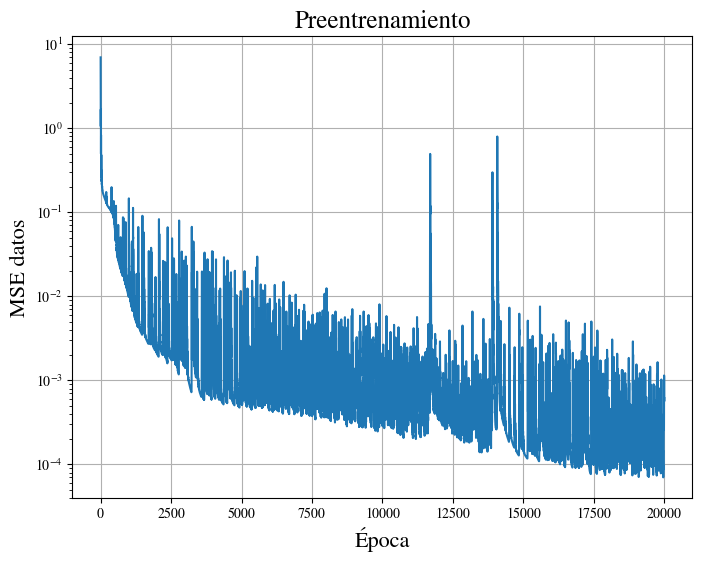

In [50]:
plt.figure(
    figsize=(8, 6)
)

plt.plot(
    loss_pre
)

plt.xlabel("Época")
plt.ylabel("MSE datos")
plt.yscale("log")
plt.title("Preentrenamiento")
plt.show()


## 11. Verificación después del preentrenamiento


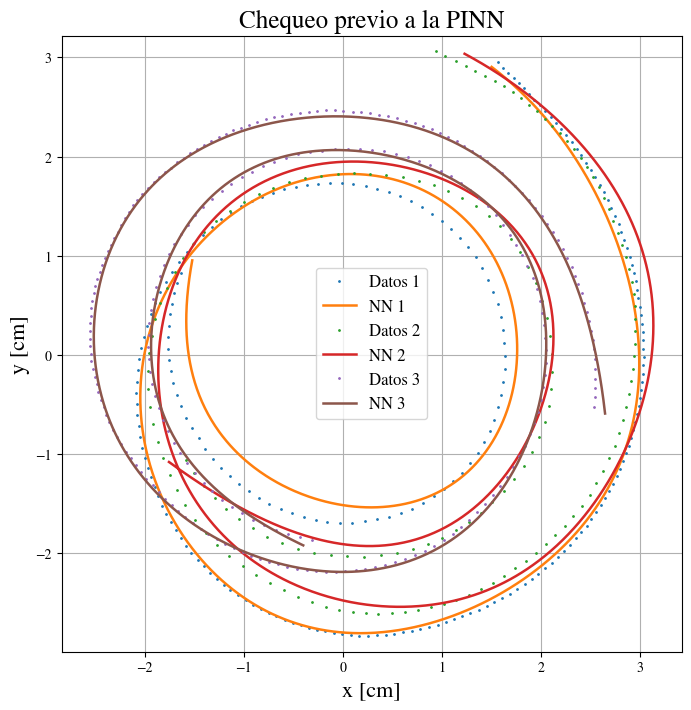

In [51]:
fig, ax = plt.subplots(
    figsize=(8, 8)
)

for i, (pinn, df) in enumerate(
    zip(pinns, dfs),
    start=1
):

    tau_eval = torch.linspace(
        -1,
        1,
        1500,
        device=device
    ).view(-1, 1)

    with torch.no_grad():

        X_estim = (
            pinn(tau_eval)
            .cpu()
            .numpy()
        )


    ax.plot(
        100 * df["x_m"],
        100 * df["y_m"],
        ".",
        ms=2,
        label=f"Datos {i}"
    )

    ax.plot(
        100 * X_estim[:, 0],
        100 * X_estim[:, 1],
        lw=1.8,
        label=f"NN {i}"
    )


ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Chequeo previo a la PINN")
ax.axis("equal")
ax.legend()

plt.show()


## 12. Etapa 2: entrenamiento de la PINN

Ahora se agrega la restricción física.

Los errores de datos y de física se normalizan con escalas características para que sean comparables.


In [ ]:
# Escalas características

L0 = 0.03     # m
U0 = 0.08     # m/s

LAMBDA_FISICA = 1.0

ITERATIONS = 20000
N_FISICA = 500


optimizer = torch.optim.Adam(
    list(pinns.parameters())
    + list(parametros.parameters()),
    lr=1e-4
)


tau_physics = [
    torch.linspace(
        -1,
        1,
        N_FISICA,
        device=device
    ).view(-1, 1).requires_grad_(True)

    for _ in range(3)
]


loss_array = np.zeros(
    ITERATIONS
)

error_datos_array = np.zeros(
    ITERATIONS
)

error_fisica_array = np.zeros(
    ITERATIONS
)


for epoch in range(
    ITERATIONS
):

    optimizer.zero_grad()

    MSDd = 0.0
    MSDf = 0.0


    for pinn, datos, tau_f in zip(
        pinns,
        datos_torch,
        tau_physics
    ):

        # ================================================
        # ERROR DE DATOS
        # ================================================

        X_pred = pinn(
            datos["tau"]
        )

        MSDd_i = torch.mean(
            (
                (
                    X_pred
                    - datos["X"]
                )
                / L0
            )**2
        )

        MSDd = (
            MSDd
            + MSDd_i
        )


        # ================================================
        # ERROR DE FÍSICA
        # ================================================

        X_f = pinn(
            tau_f
        )

        x_f = X_f[:, 0]
        y_f = X_f[:, 1]


        dx_dtau = torch.autograd.grad(
            x_f,
            tau_f,
            torch.ones_like(x_f),
            create_graph=True
        )[0]


        dy_dtau = torch.autograd.grad(
            y_f,
            tau_f,
            torch.ones_like(y_f),
            create_graph=True
        )[0]


        # Conversión de derivada respecto de tau
        # a derivada respecto del tiempo físico.

        factor_tiempo = (
            2.0 / datos["T"]
        )


        dX_dt = torch.cat(
            (
                dx_dtau * factor_tiempo,
                dy_dtau * factor_tiempo
            ),
            dim=1
        )


        velocidad = velocidad_burgers(
            X_f,
            parametros
        )


        MSDf_i = torch.mean(
            (
                (
                    dX_dt
                    - velocidad
                )
                / U0
            )**2
        )


        MSDf = (
            MSDf
            + MSDf_i
        )


    MSDd = (
        MSDd / len(pinns)
    )

    MSDf = (
        MSDf / len(pinns)
    )


    loss = (
        MSDd
        + LAMBDA_FISICA * MSDf
    )


    loss.backward()

    optimizer.step()


    loss_array[epoch] = (
        loss.detach()
        .cpu()
        .item()
    )

    error_datos_array[epoch] = (
        MSDd.detach()
        .cpu()
        .item()
    )

    error_fisica_array[epoch] = (
        MSDf.detach()
        .cpu()
        .item()
    )


    if epoch % 1000 == 0:

        print(
            f"Época {epoch:5d} | "
            f"Datos = {MSDd.item():.3e} | "
            f"Física = {MSDf.item():.3e} | "
            f"Loss = {loss.item():.3e}"
        )


## 13. Evolución de la función de pérdida


In [ ]:
epocas = np.arange(
    ITERATIONS
)

plt.figure(
    figsize=(9, 7)
)

plt.plot(
    epocas,
    loss_array,
    label="Error total"
)

plt.plot(
    epocas,
    error_datos_array,
    label="Error datos"
)

plt.plot(
    epocas,
    error_fisica_array,
    label="Error física"
)

plt.xlabel("Época")
plt.ylabel("Error adimensional")
plt.yscale("log")
plt.legend()

plt.show()


## 14. Trayectorias experimentales vs PINN


In [ ]:
fig, ax = plt.subplots(
    figsize=(8, 8)
)

for i, (pinn, df) in enumerate(
    zip(pinns, dfs),
    start=1
):

    tau_eval = torch.linspace(
        -1,
        1,
        1500,
        device=device
    ).view(-1, 1)

    with torch.no_grad():

        X_estim = (
            pinn(tau_eval)
            .cpu()
            .numpy()
        )


    ax.plot(
        100 * df["x_m"],
        100 * df["y_m"],
        ".",
        ms=2,
        label=f"Datos {i}"
    )

    ax.plot(
        100 * X_estim[:, 0],
        100 * X_estim[:, 1],
        lw=2,
        label=f"PINN {i}"
    )


ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Trayectorias: datos vs PINN")
ax.axis("equal")
ax.legend()

plt.show()


## 15. Parámetros aprendidos


In [ ]:
alpha = (
    parametros.alp
    .detach()
    .cpu()
    .item()
)

Gamma = (
    parametros.Gam
    .detach()
    .cpu()
    .item()
)

r0 = (
    parametros.r0
    .detach()
    .cpu()
    .item()
)

xc = (
    parametros.xc
    .detach()
    .cpu()
    .item()
)

yc = (
    parametros.yc
    .detach()
    .cpu()
    .item()
)


print(
    f"alpha = {alpha:.6g} 1/s"
)

print(
    f"Gamma = {Gamma:.6g} m²/s"
)

print(
    f"r0 = {r0:.6g} m"
)

print(
    f"xc = {xc:.6g} m"
)

print(
    f"yc = {yc:.6g} m"
)


## 16. Campo de velocidades reconstruido


In [ ]:
todos_x = np.concatenate(
    [
        df["x_m"].values
        for df in dfs
    ]
)

todos_y = np.concatenate(
    [
        df["y_m"].values
        for df in dfs
    ]
)


margen = 0.005


xmin = (
    todos_x.min()
    - margen
)

xmax = (
    todos_x.max()
    + margen
)

ymin = (
    todos_y.min()
    - margen
)

ymax = (
    todos_y.max()
    + margen
)


x_grid = np.linspace(
    xmin,
    xmax,
    31
)

y_grid = np.linspace(
    ymin,
    ymax,
    31
)


Xg, Yg = np.meshgrid(
    x_grid,
    y_grid
)


XY = torch.tensor(
    np.column_stack(
        (
            Xg.ravel(),
            Yg.ravel()
        )
    ),
    dtype=torch.float32,
    device=device
)


with torch.no_grad():

    UV = (
        velocidad_burgers(
            XY,
            parametros
        )
        .cpu()
        .numpy()
    )


Ug = UV[:, 0].reshape(
    Xg.shape
)

Vg = UV[:, 1].reshape(
    Yg.shape
)

modulo = np.sqrt(
    Ug**2
    + Vg**2
)


fig, ax = plt.subplots(
    figsize=(9, 8)
)


q = ax.quiver(
    100 * Xg,
    100 * Yg,
    Ug,
    Vg,
    modulo
)


for i, df in enumerate(
    dfs,
    start=1
):

    ax.plot(
        100 * df["x_m"],
        100 * df["y_m"],
        lw=1.2,
        label=f"Trayectoria {i}"
    )


ax.scatter(
    [100 * xc],
    [100 * yc],
    marker="x",
    s=100,
    label="Centro aprendido"
)


ax.set_xlabel("x [cm]")
ax.set_ylabel("y [cm]")
ax.set_title("Campo de velocidades reconstruido")
ax.axis("equal")
ax.legend()


cbar = plt.colorbar(
    q,
    ax=ax
)

cbar.set_label(
    "|u| [m/s]"
)


plt.show()


## 17. Perfiles radial y tangencial


In [ ]:
r_max = np.max(
    np.sqrt(
        (todos_x - xc)**2
        + (todos_y - yc)**2
    )
)


r = np.linspace(
    1e-5,
    r_max,
    500
)


u_r = (
    -alpha * r
)


u_theta = (
    Gamma
    / (2 * np.pi * r)
    * (
        1
        - np.exp(
            -r**2 / r0**2
        )
    )
)


plt.figure(
    figsize=(9, 7)
)

plt.plot(
    100 * r,
    100 * u_r,
    label="Velocidad radial"
)

plt.plot(
    100 * r,
    100 * u_theta,
    label="Velocidad tangencial"
)

plt.xlabel("r [cm]")
plt.ylabel("Velocidad [cm/s]")
plt.title("Perfiles del campo aprendido")
plt.legend()

plt.show()
